# Вычислительное музыковедение: Модели и методы Music Data Mining

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Лабораторная работа №5. Инструменты работы с нейронными сетями

### Работа с данными

Полезные ссылки:
1. http://ismir2001.ismir.net/pdf/tzanetakis.pdf
2. https://huggingface.co/datasets/marsyas/gtzan

In [3]:
!pip install datasets

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 510.5/510.5 kB 6.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 7.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.1/194.1 kB 9.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 134.8/134.8 kB 8.8 MB/s eta 0:00:00


In [4]:
from datasets import load_dataset

dataset = load_dataset("marsyas/gtzan")

/usr/local/lib/python3.10/dist-packages/huggingface_hub/utils/_token.py:88: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/datasets/load.py:1461: FutureWarning: The repository for marsyas/gtzan contains custom code which must be executed to correctly load the dataset. You can inspect the repository content at https://hf.co/datasets/marsyas/gtzan
You can avoid this message in future by passing the argument `trust_remote_code=True`.
Passing `trust_remote_code=True` will be mandatory to load this dataset from the next major release of `datasets`.
  warnings.war

Generating train split: 0 examples [00:00, ? examples/s]

GTZAN is a dataset for musical genre classification of audio signals. The dataset consists of 1,000 audio tracks, each of 30 seconds long. It contains 10 genres, each represented by 100 tracks. The tracks are all 22,050Hz Mono 16-bit audio files in WAV format. The genres are: blues, classical, country, disco, hiphop, jazz, metal, pop, reggae, and rock.

In [5]:
dataset

DatasetDict({
    train: Dataset({
        features: ['file', 'audio', 'genre'],
        num_rows: 999
    })
})

In [6]:
dataset['train'][998]

{'file': '/root/.cache/huggingface/datasets/downloads/extracted/5022b0984afa7334ff9a3c60566280b08b5179d4ac96a628052bada7d8940244/genres/rock/rock.00099.wav',
 'audio': {'path': '/root/.cache/huggingface/datasets/downloads/extracted/5022b0984afa7334ff9a3c60566280b08b5179d4ac96a628052bada7d8940244/genres/rock/rock.00099.wav',
  'array': array([-0.02111816, -0.03451538, -0.03536987, ...,  0.00134277,
          0.00250244, -0.00186157]),
  'sampling_rate': 22050},
 'genre': 9}

In [7]:
num2class = {
    0: 'blues',
    1: 'classical',
    2: 'country',
    3: 'disco',
    4: 'hiphop',
    5: 'jazz',
    6: 'metal',
    7: 'pop',
    8: 'reggae',
    9: 'rock'
}

In [8]:
import IPython.display as ipd

idx = 111

print(dataset['train'][idx]['file'].split('/')[-1]) # num2class[...]
print(num2class.get(dataset['train'][idx]['genre'], 'Unknown')) # num2class[...]
ipd.Audio(dataset['train'][idx]['audio']['array'], rate=dataset['train'][idx]['audio']['sampling_rate'])

classical.00011.wav
classical


### Инстурмент Open SMILE

In [9]:
!pip install opensmile

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 996.2/996.2 kB 10.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 4.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 8.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.9/140.9 kB 10.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 20.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 138.4/138.4 kB 3.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.4/167.4 kB 17.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for iso-639: filename=iso_639-0.4.5-py3-none-any.whl size=168840 sha256=40a1cfe28fac8d2c204a1cf19a761adcc5ba8ca9296ba45721637cd2792ad9fb
  Stored in directory: /root/.cache/pip/wheels/d8/78/cc/5478ca3b1c3f602eae6f8cdbd78f909c0a0bfa0bbcb5c7771f
Successfully built iso-639


In [10]:
signal = dataset['train'][idx]['audio']['array']
sr = dataset['train'][idx]['audio']['sampling_rate']

Извлекаемые множества признаки: https://audeering.github.io/opensmile-python/api/opensmile.FeatureSet.html

In [11]:
import opensmile

smile = opensmile.Smile(
    feature_set=opensmile.FeatureSet.eGeMAPSv02,
    feature_level=opensmile.FeatureLevel.LowLevelDescriptors,
)
smile.feature_names

['Loudness_sma3',
 'alphaRatio_sma3',
 'hammarbergIndex_sma3',
 'slope0-500_sma3',
 'slope500-1500_sma3',
 'spectralFlux_sma3',
 'mfcc1_sma3',
 'mfcc2_sma3',
 'mfcc3_sma3',
 'mfcc4_sma3',
 'F0semitoneFrom27.5Hz_sma3nz',
 'jitterLocal_sma3nz',
 'shimmerLocaldB_sma3nz',
 'HNRdBACF_sma3nz',
 'logRelF0-H1-H2_sma3nz',
 'logRelF0-H1-A3_sma3nz',
 'F1frequency_sma3nz',
 'F1bandwidth_sma3nz',
 'F1amplitudeLogRelF0_sma3nz',
 'F2frequency_sma3nz',
 'F2bandwidth_sma3nz',
 'F2amplitudeLogRelF0_sma3nz',
 'F3frequency_sma3nz',
 'F3bandwidth_sma3nz',
 'F3amplitudeLogRelF0_sma3nz']

In [12]:
smile.process_signal(
    signal, sr
)

,,Loudness_sma3,alphaRatio_sma3,hammarbergIndex_sma3,slope0-500_sma3,slope500-1500_sma3,spectralFlux_sma3,mfcc1_sma3,mfcc2_sma3,mfcc3_sma3,mfcc4_sma3,...,logRelF0-H1-A3_sma3nz,F1frequency_sma3nz,F1bandwidth_sma3nz,F1amplitudeLogRelF0_sma3nz,F2frequency_sma3nz,F2bandwidth_sma3nz,F2amplitudeLogRelF0_sma3nz,F3frequency_sma3nz,F3bandwidth_sma3nz,F3amplitudeLogRelF0_sma3nz
start,end,,,,,,,,,,,,,,,,,,,,,
0 days 00:00:00,0 days 00:00:00.020000,0.616998,-6.081289,12.642415,0.018853,-0.024449,0.047097,22.321638,-9.760304,5.344826,-5.867167,...,11.392544,443.104584,1113.729614,2.397139,1449.308960,972.983398,-10.694065,2487.810791,949.879578,-9.595878
0 days 00:00:00.010022676,0 days 00:00:00.030022676,0.618532,-7.344420,13.142392,0.023633,-0.020717,0.104154,22.739700,-8.581505,7.408136,-9.039139,...,12.503006,544.170410,1214.276611,0.000000,1634.653931,932.848145,-12.716716,2696.301514,915.339355,-11.694969
0 days 00:00:00.020045351,0 days 00:00:00.040045351,0.622960,-9.093999,14.238187,0.031828,-0.016394,0.167983,22.507935,-6.816754,9.184848,-13.005357,...,12.532550,673.189941,1250.685791,0.379864,1794.313965,875.926086,-12.276127,2875.066406,804.056396,-12.080731
0 days 00:00:00.030068027,0 days 00:00:00.050068027,0.615778,-9.132001,11.456280,0.048014,-0.019908,0.186342,21.218586,-5.120774,9.476525,-13.455940,...,14.133728,770.916443,1324.569092,1.558449,1943.182251,721.071106,-9.983392,3039.956055,759.712891,-12.575278
0 days 00:00:00.040090703,0 days 00:00:00.060090703,0.603381,-7.937592,10.832192,0.048651,-0.020959,0.203530,19.551813,-3.528833,11.054545,-7.971434,...,14.472516,626.845032,1389.055054,2.622048,1739.434448,754.724182,-5.151148,2966.456055,774.165833,-10.384744
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
0 days 00:00:29.917687075,0 days 00:00:29.937687075,0.170535,-2.343140,4.704902,-0.030410,-0.026070,0.018246,8.151047,-21.351248,1.732835,-15.978424,...,1.187482,435.628540,1228.511475,0.000000,1502.593872,1579.015747,-2.061458,2270.860596,1048.166504,-10.453495
0 days 00:00:29.927709751,0 days 00:00:29.947709751,0.173180,-2.561466,6.585139,-0.022819,-0.026244,0.019820,7.364591,-20.239168,4.552948,-17.119429,...,-8.442597,459.584473,922.548523,0.000000,1535.689453,849.583557,-2.053082,2468.706299,938.064392,-5.309783
0 days 00:00:29.937732426,0 days 00:00:29.957732426,0.170760,-3.785945,9.244433,-0.042694,-0.031378,0.021083,7.198791,-18.776623,5.748409,-17.757212,...,-10.657845,488.898346,789.177429,0.000000,1548.398804,719.236877,-3.051175,2553.667969,814.538330,-5.877562


In [13]:
smile = opensmile.Smile()
result = smile.process_signal(
    signal, sr
)
result

,,audspec_lengthL1norm_sma_range,audspec_lengthL1norm_sma_maxPos,audspec_lengthL1norm_sma_minPos,audspec_lengthL1norm_sma_quartile1,audspec_lengthL1norm_sma_quartile2,audspec_lengthL1norm_sma_quartile3,audspec_lengthL1norm_sma_iqr1-2,audspec_lengthL1norm_sma_iqr2-3,audspec_lengthL1norm_sma_iqr1-3,audspec_lengthL1norm_sma_percentile1.0,...,mfcc_sma_de[14]_peakRangeAbs,mfcc_sma_de[14]_peakRangeRel,mfcc_sma_de[14]_peakMeanAbs,mfcc_sma_de[14]_peakMeanMeanDist,mfcc_sma_de[14]_peakMeanRel,mfcc_sma_de[14]_minRangeRel,mfcc_sma_de[14]_meanRisingSlope,mfcc_sma_de[14]_stddevRisingSlope,mfcc_sma_de[14]_meanFallingSlope,mfcc_sma_de[14]_stddevFallingSlope
start,end,,,,,,,,,,,,,,,,,,,,,
0 days,0 days 00:00:30.013333333,0.739473,0.12454,0.993639,0.361962,0.421418,0.501554,0.059456,0.080136,0.139592,0.186169,...,7.229427,0.558557,1.993228,1.998537,-19.98591,0.768963,93.221306,46.487316,92.442406,45.212151


In [14]:
result.to_numpy()

array([[ 0.7394734 ,  0.12453967,  0.9936391 , ..., 46.487316  ,
        92.442406  , 45.21215   ]], dtype=float32)

### Подготовка датасета

In [15]:
# from tqdm import tqdm

# smile = opensmile.Smile()

# prepared_data = []

# for idx in tqdm(range(len(dataset['train']))):
#     signal = dataset['train'][idx]['audio']['array']
#     sr = dataset['train'][idx]['audio']['sampling_rate']
#     genre = dataset['train'][idx]['genre']
#     features = smile.process_signal(signal, sr).to_numpy()[0]
#     prepared_data.append({
#         'id': idx,
#         'features': features,
#         'genre': genre
#     })


In [16]:
import numpy as np
# Сохранить
file_name = '/content/drive/MyDrive/ВычМуз/ЛР3/smile_features.npy'
# np.save(file_name, prepared_data, allow_pickle=True) # Не забудьте закомментировать, чтобы не перезаписать или еще что.

# Извлечь
data = np.load(file_name, allow_pickle=True)
len(data)

999

### Нейронки

#### Comet ML

https://www.comet.com/site/

Читаем, изучаем: https://www.comet.com/docs/v2/api-and-sdk/python-sdk/reference/Experiment/#experimentlog_model

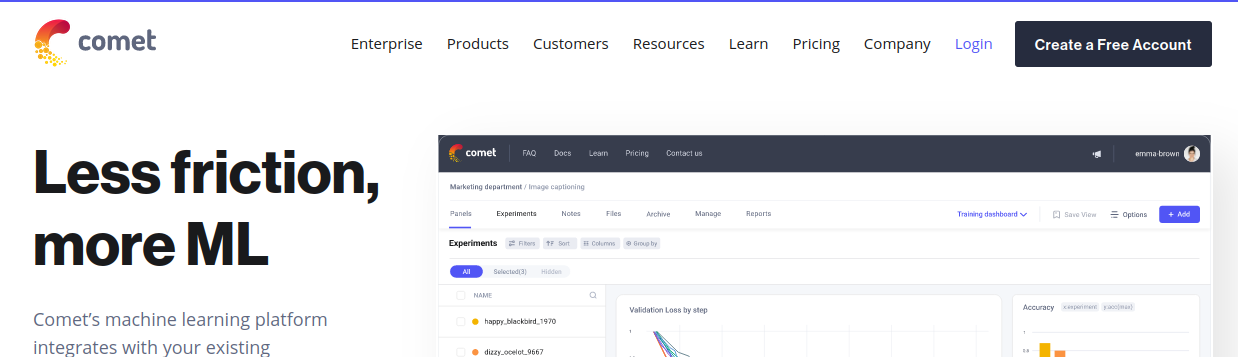

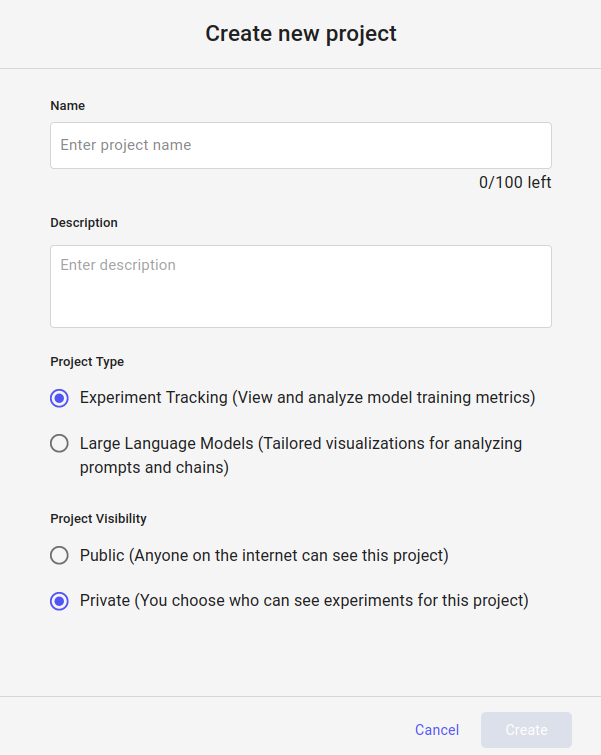

In [17]:
!pip install comet_ml

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 645.1/645.1 kB 9.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 20.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 6.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 267.1/267.1 kB 25.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.9/137.9 kB 16.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.3/54.3 kB 6.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 514.7/514.7 kB 39.1 MB/s eta 0:00:00
  Attempting uninstall: websocket-client
    Found existing installation: websocket-client 1.7.0
    Uninstalling websocket-client-1.7.0:
      Successfully uninstalled websocket-client-1.7.0
  Attempting uninstall: python-box
    Found existing installation: python-box 7.1.1
    Uninstalling python-box-7.1.1:
      Successfully uninstalled python-box-7.1.1


In [18]:
from comet_ml import Experiment
from comet_ml.integration.pytorch import log_model

experiment = Experiment(
  api_key="fv5jiKo2z6mX7FmrY2sFBqaRJ",
  project_name="vychmuz5",
  workspace="ilyadenisov88"
)

COMET WARNING: As you are running in a Jupyter environment, you will need to call `experiment.end()` when finished to ensure all metrics and code are logged before exiting.
COMET INFO: Couldn't find a Git repository in '/content' nor in any parent directory. Set `COMET_GIT_DIRECTORY` if your Git Repository is elsewhere.
COMET INFO: Experiment is live on comet.com https://www.comet.com/ilyadenisov88/vychmuz5/07b7fd971ca34919b8e8578c3f3108bd



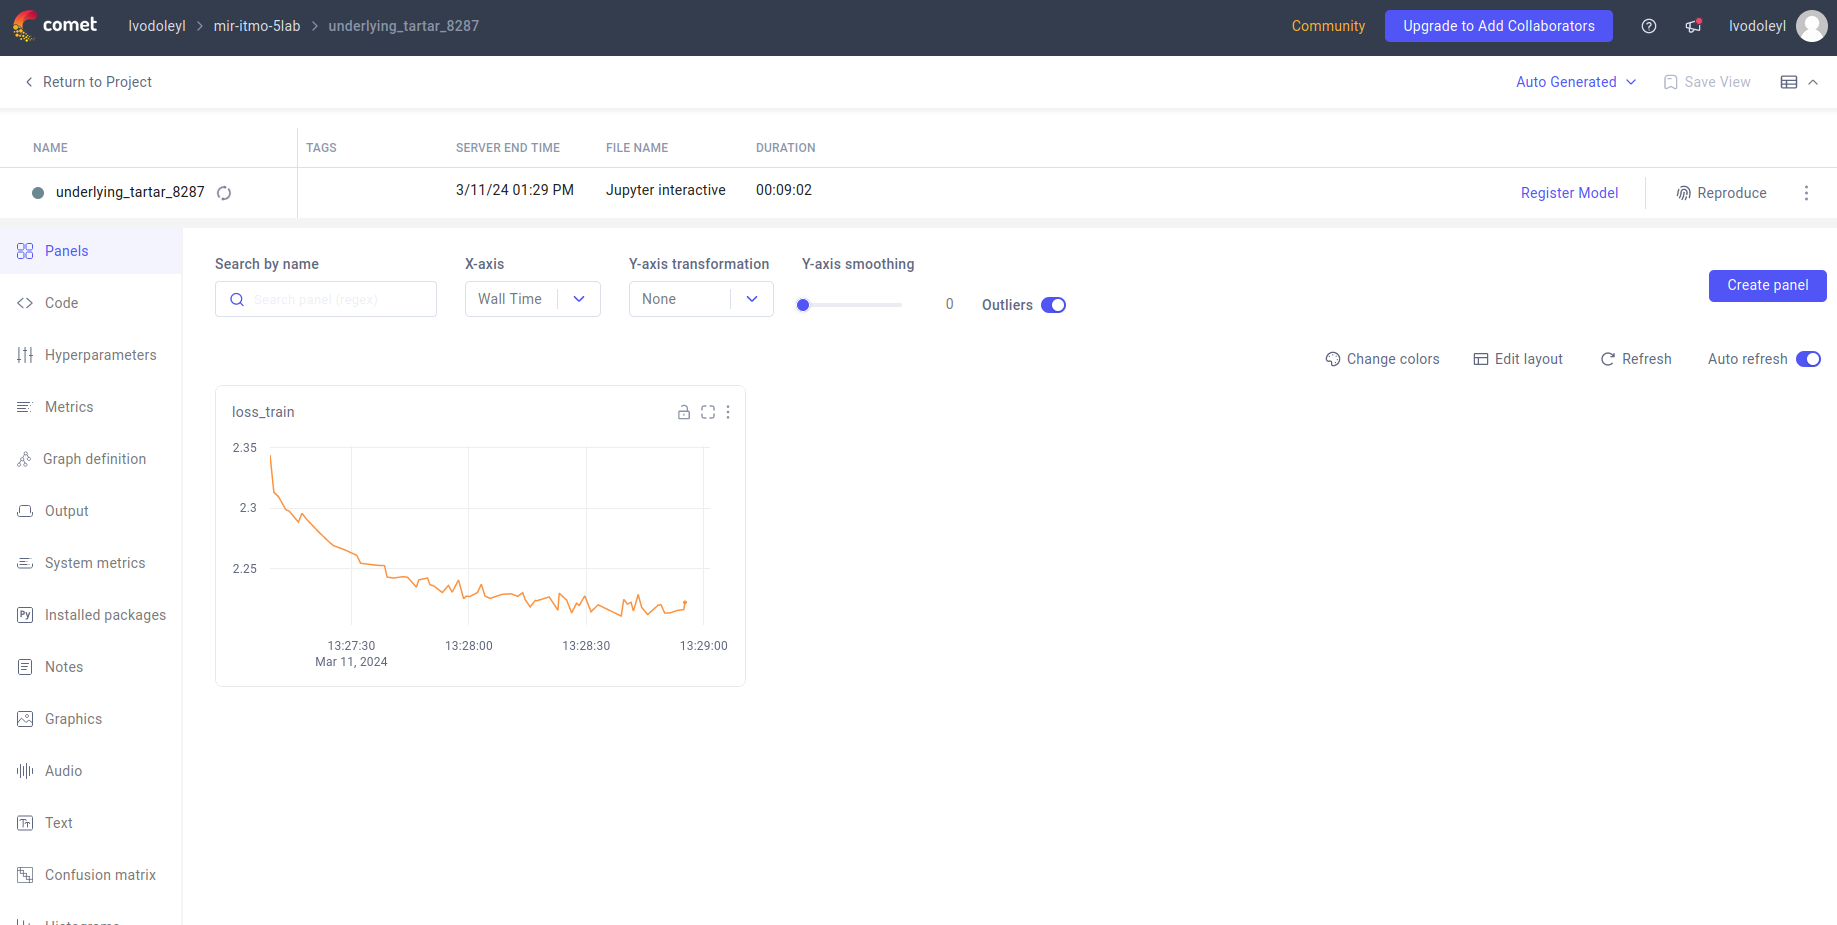

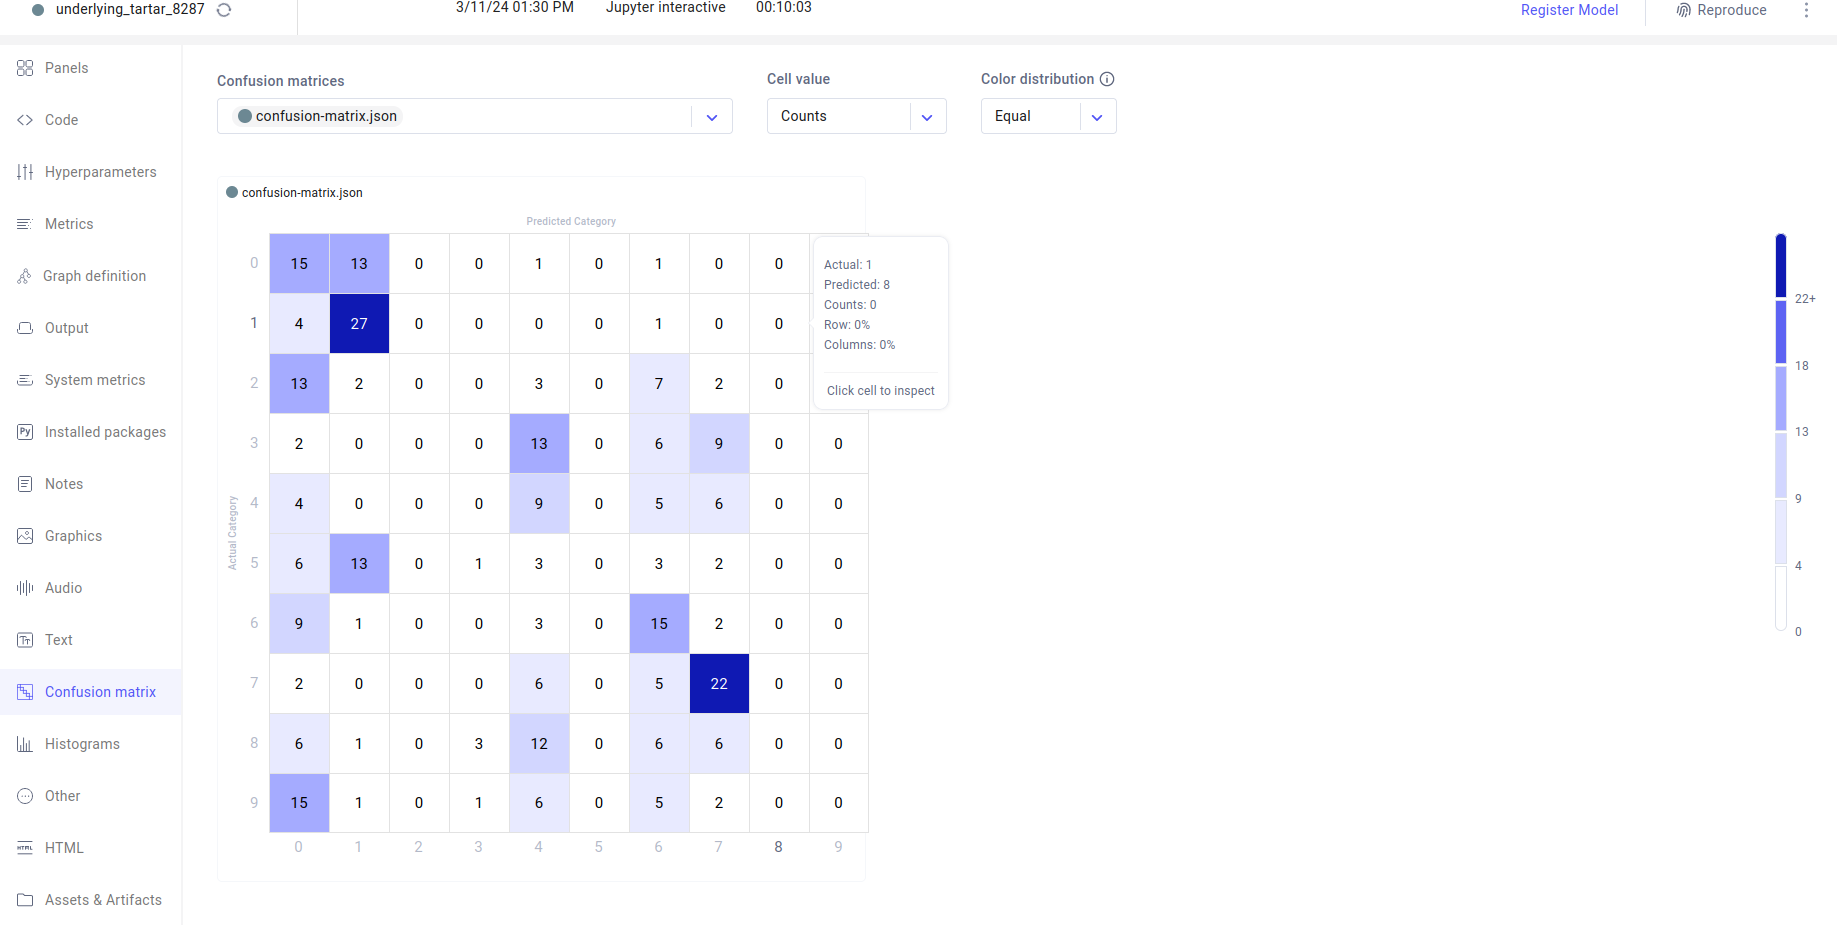

### Задание на лабораторную работу (10 баллов)

1. Произведите доработку кода:  
      I. Разделите итоговый набор данных на: трейновую, валидационную и тестовую выборки (например 70\15\15). Для упрощения жизни можете сделать 70 / 30, валидационная = тестовая.   
      II. В коцнце каждой эпохи на валидационной выборке посчитайте метрики (3 штуки) и залогируйте их. Попробуйте посчитать метрики на трейновой выборке во время обучения.
2. Обучить 3 различных полносвязных нейронных сети (различные функции активации; количество нейронов, слоев; использование нормализации или, наоборот, без нормализации; различные оптимизаторы, или, например, добавть расписание для оптимизаторв; батч нормализация)
3. Расчитать метрики: acc, f-1 и третья - на ваш выбор
4. Сохраните все 3 полученные нейронные сети в чекпоинты.
4. Для каждого эксперемента произвести анализ confuision matrix
5. В конце создать итоговую таблицу с эксперминетами и результатами. Сделать выводы.
6. Изучите возможности comet ml, добавьте интересное логирование, например, аудио и его метка от НС. Во время защиты продемонстрируйте, что вы налогировали в comet ml.

### Доработка кода




In [19]:
from sklearn.model_selection import train_test_split

#train=0.7 validation=0.15 test=0.15
train_data, test_data = train_test_split(data, test_size=0.15, random_state=111)

train_data, val_data = train_test_split(train_data, test_size=0.176, random_state=111) # 0.176 x 0.85 = 0.15 (примерно)


In [20]:
len(train_data), len(test_data), len(val_data)

(699, 150, 150)

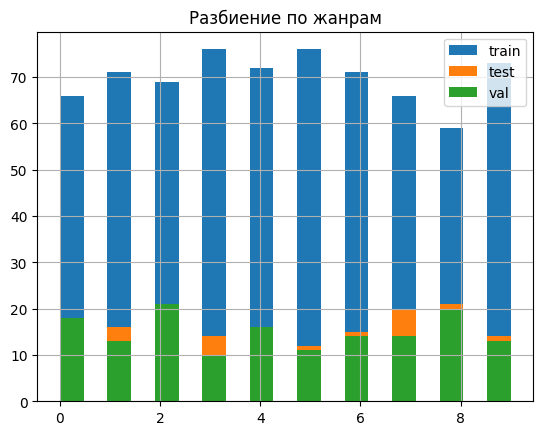

In [21]:
# если время останется сделать нормальный график
import matplotlib.pyplot as plt


plt.hist([elem['genre'] for elem in train_data], 19, label='train')
plt.hist([elem['genre'] for elem in test_data], 19, label='test')
plt.hist([elem['genre'] for elem in val_data], 19, label='val')

plt.legend()
plt.title('Разбиение по жанрам')
plt.grid()
plt.show()

### PyTotch

In [22]:
import torch

print(torch.__version__) # версия pytorch
print(torch.version.cuda) # cuda version
print(torch.cuda.is_available()) # Проверить, доступен ли cuda

2.2.1+cu121
12.1
True


In [23]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda')

In [24]:
from torch.utils.data import Dataset, DataLoader

class GenreDataset(Dataset):
  def __init__(self, data, mean = None, std = None):
    features = np.array([elem['features'] for elem in data])
    if not mean:
      self.mean = features.mean()
      self.std = features.std()
    else:
      self.mean = mean
      self.std = std
    self.features = torch.Tensor((features - self.mean) / self.std)
    self.genre = torch.Tensor([elem['genre'] for elem in data]).to(torch.long) #, dtype=torch.long)

  def __getitem__(self, index):
    return self.features[index], self.genre[index]

  def __len__(self):
    return self.genre.size(0)


traindataset = GenreDataset(train_data)
testdataset = GenreDataset(test_data, traindataset.mean, traindataset.std)
valdataset = GenreDataset(val_data, traindataset.mean, traindataset.std)


In [25]:
TRAIN_BATCH_SIZE = 8
TEST_BATCH_SIZE = 8

experiment.log_parameter("TRAIN_BATCH_SIZE", TRAIN_BATCH_SIZE)
experiment.log_parameter("TEST_BATCH_SIZE", TEST_BATCH_SIZE)

trainloader = DataLoader(traindataset, batch_size=16, shuffle=True)
testloader = DataLoader(testdataset, batch_size=16, shuffle=False)
valloader = DataLoader(valdataset, batch_size=16, shuffle=False)

In [26]:
import torch.nn as nn
import torch.nn.functional as F

In [162]:
class FeedForwNet(nn.Module):
  def __init__(self):
    super(FeedForwNet, self).__init__()
    self.fc1 = nn.Linear(6373, 1000)
    self.fc2 = nn.Linear(1000, 10)
    self.fc3 = nn.Linear(10, 10) # добавил ещё один слой
    self.d = nn.Dropout(p=0.2)

  def forward(self, x):
    x = self.d(F.tanh(self.fc1(x)))
    x = F.tanh(self.fc2(x))
    x = F.softmax(self.fc3(x))
    return x

In [163]:
!pip install torchmetrics

In [164]:
valY = []
valX = []

for el in val_data:
  valY.append(el['genre'])
  valX.append(el['features'])

In [166]:
from sklearn.metrics import accuracy_score

def predict(x, network):
  network.eval()
  with torch.no_grad():
    predited_label = network(x.float())
  return predited_label.argmax(1)

def get_score(loader, network):
  y_true = []
  y_pred = []
  for idx, (x, y) in enumerate(loader):
    x = x.to(device)
    y_pred.extend(list(predict(x, network).cpu().detach().numpy()))
    y_true.extend(list(y.detach().numpy()))
  return accuracy_score(y_true, y_pred), y_true, y_pred

In [175]:
from tqdm import tqdm
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from torchmetrics.classification import MulticlassAccuracy

from torch.optim.lr_scheduler import StepLR



# Создаем сеть
net = FeedForwNet().to(device)
net.train()
experiment.log_parameters(net.parameters())
# Определяем функцию потерь
loss_fn = torch.nn.CrossEntropyLoss()
# выбираем алгоритм оптимизации и learning_rate
learning_rate = 0.0001
experiment.log_parameter("learning_rate", learning_rate)
optimizer = torch.optim.Adam(net.parameters(), lr=learning_rate)
#optimizer = torch.optim.SGD(net.parameters(), lr=learning_rate)#, momentum=0.8)
# Задаем количество эпох
EPOCHES = 300
experiment.log_parameter("EPOCHES", EPOCHES)


loss_for_draw = []
train_accuracy_for_draw = []
train_precision_for_draw = []
train_recall_for_draw = []

val_accuracy_for_draw = []
val_precision_for_draw = []
val_recall_for_draw = []
val_f1_for_draw = []

# расписание
#scheduler = StepLR(optimizer, step_size=3, gamma=0.001)

# итерируемся
for epoch in tqdm(range(EPOCHES)):

    print("="*10 + f" {epoch + 1} epoch " + "="*10 )

    running_loss = 0.0
    loss_all = 0.0
    for i, (data, target) in enumerate(trainloader):

        # текущий батч
        X_batch, y_batch = data.to(device), target.to(device)

        # обнуляем grad
        optimizer.zero_grad()

        # forward + backward + optimize
        y_pred = net(X_batch)

        loss = loss_fn(y_pred, y_batch)
        # print(f'y_batch_shape: {y_batch.shape}, y_pred_shape: {y_pred.shape}')
        metric = MulticlassAccuracy(num_classes=10).to(device)
        accuracy_train = metric(y_pred, y_batch).cpu().item() # это я сделал на трейне


        loss.backward()
        optimizer.step()

        # выведем текущий loss
        running_loss += loss.item()
        loss_all += loss.item()


        # выведем метрики каждые 40 батчей
        if i % 40 == 39:
            print('[%d, %5d] loss: %.3f' %
                  (epoch + 1, i + 1, running_loss / 40))
            # print('accuracy_score:', accuracy)

            running_loss = 0.0
        count = i
    # подсчет val_accuracy
    val_pred_tensor = net(torch.tensor(valX).to(device))
    val_pred = val_pred_tensor.argmax(1).cpu().detach().numpy()

    acc = accuracy_score(valY, val_pred)
    prec = precision_score(valY, val_pred, average='weighted')
    rec = recall_score(valY, val_pred, average='weighted')
    f1 = f1_score(valY, val_pred, average='weighted')



    loss_for_draw.append(loss_all / count)
    train_accuracy_for_draw.append(accuracy_train)

    val_accuracy_for_draw.append(acc)
    val_precision_for_draw.append(prec)
    val_recall_for_draw.append(rec)
    val_f1_for_draw.append(f1)



    experiment.log_metric('loss_train', loss_all / count)

    #scheduler.step()



print('Обучение закончено')

  0%|          | 0/300 [00:00<?, ?it/s]<ipython-input-162-95ec97eefdfc>:12: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  x = F.softmax(self.fc3(x))


========== 1 epoch ==========
[1,    40] loss: 2.297


/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
  0%|          | 1/300 [00:00<03:21,  1.49it/s]<ipython-input-162-95ec97eefdfc>:12: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  x = F.softmax(self.fc3(x))


========== 2 epoch ==========
[2,    40] loss: 2.287


/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
  1%|          | 2/300 [00:01<03:29,  1.42it/s]<ipython-input-162-95ec97eefdfc>:12: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  x = F.softmax(self.fc3(x))


...

========== 299 epoch ==========
[299,    40] loss: 2.157


/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
100%|█████████▉| 299/300 [02:30<00:00,  2.07it/s]<ipython-input-162-95ec97eefdfc>:12: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  x = F.softmax(self.fc3(x))


========== 300 epoch ==========
[300,    40] loss: 2.161


/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
100%|██████████| 300/300 [02:31<00:00,  1.98it/s]

Обучение закончено


### Графички

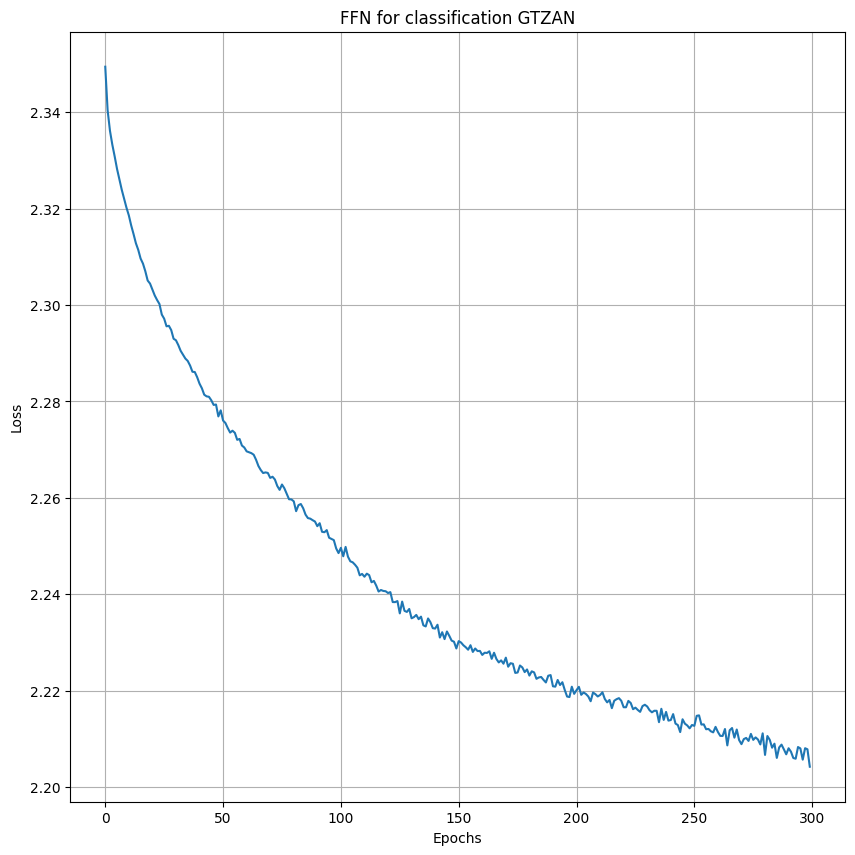

In [176]:
import matplotlib.pyplot as plt

plt.plot(loss_for_draw)
plt.title('FFN for classification GTZAN')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.grid()
plt.show()

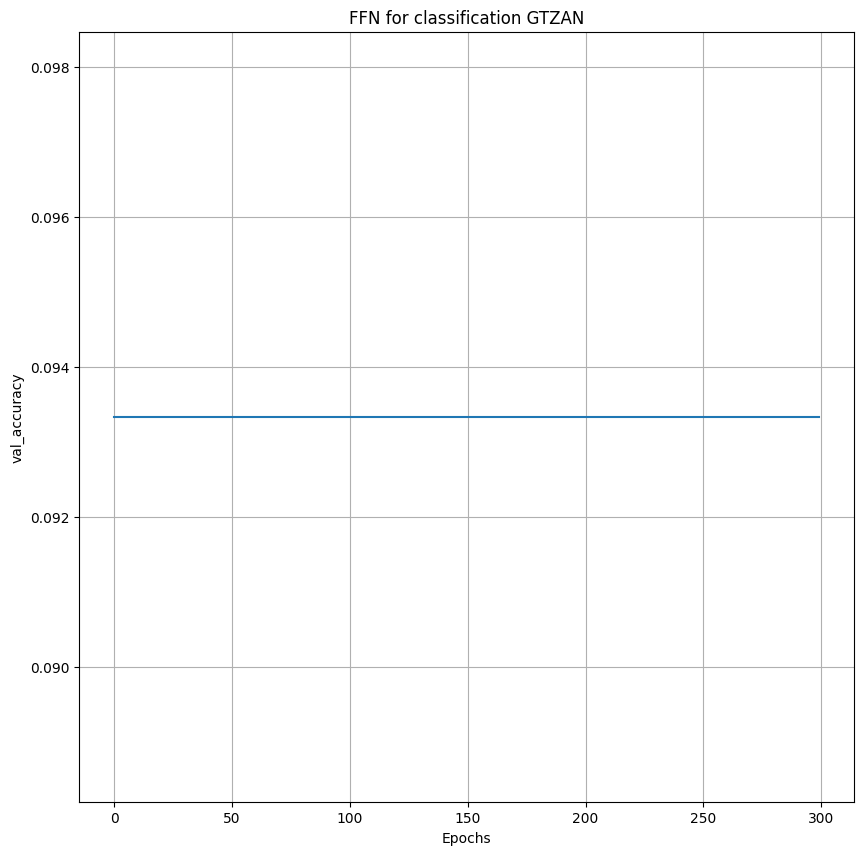

In [177]:
import matplotlib.pyplot as plt

plt.plot(val_accuracy_for_draw)
plt.title('FFN for classification GTZAN')
plt.xlabel('Epochs')
plt.ylabel('val_accuracy')
plt.grid()
plt.show()

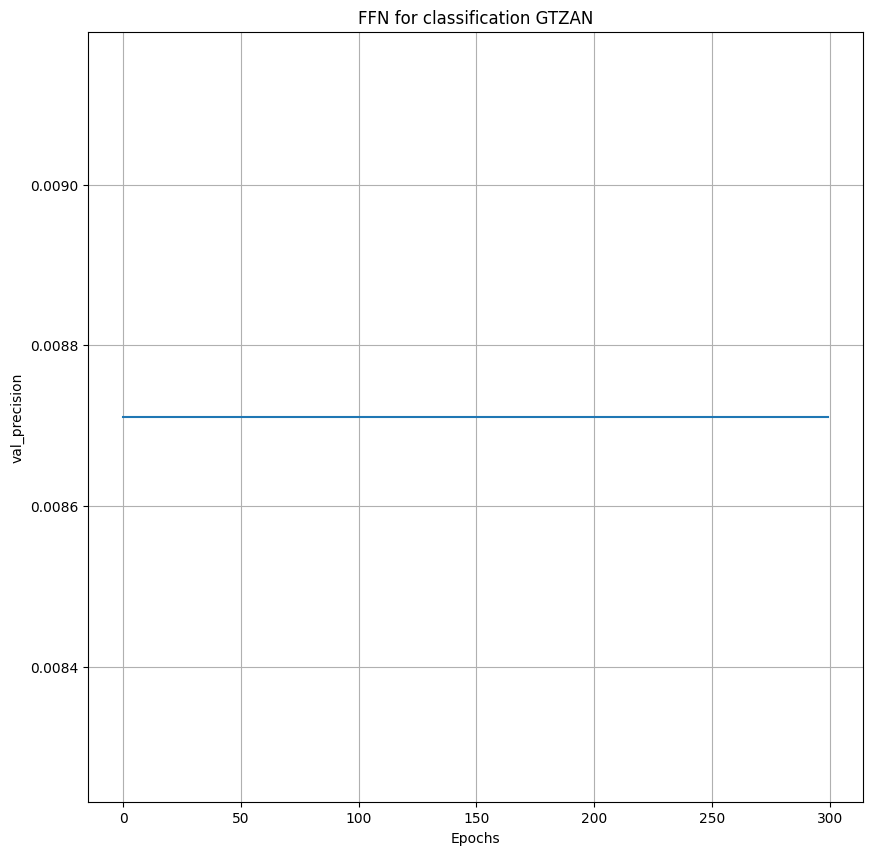

In [178]:
import matplotlib.pyplot as plt

plt.plot(val_precision_for_draw)
plt.title('FFN for classification GTZAN')
plt.xlabel('Epochs')
plt.ylabel('val_precision')
plt.grid()
plt.show()

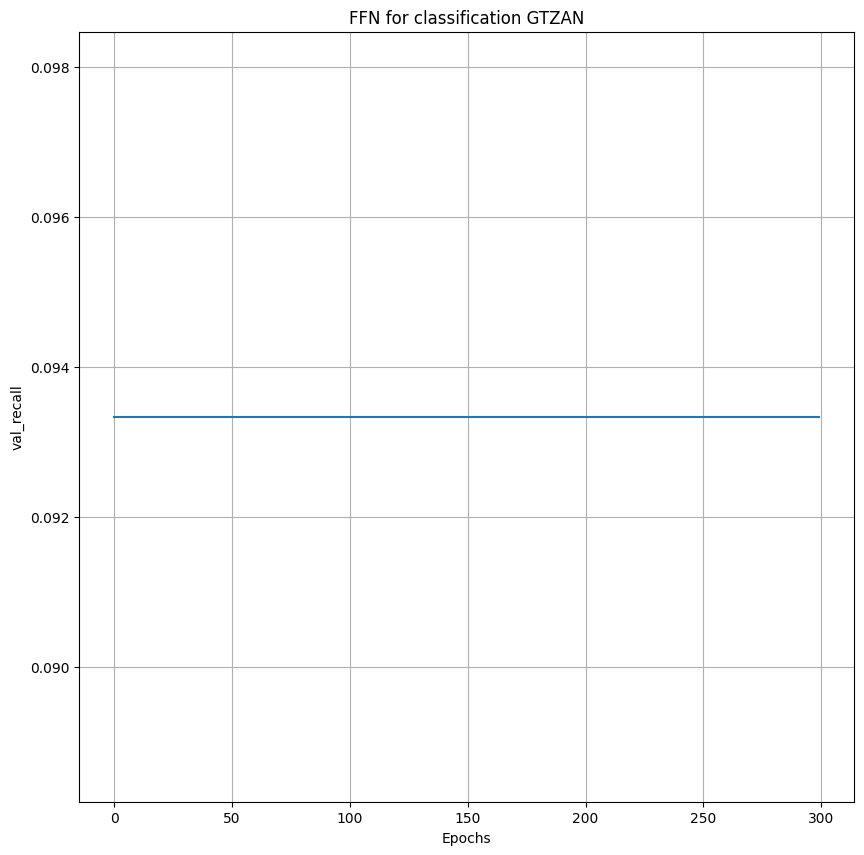

In [179]:
import matplotlib.pyplot as plt

plt.plot(val_recall_for_draw)
plt.title('FFN for classification GTZAN')
plt.xlabel('Epochs')
plt.ylabel('val_recall')
plt.grid()
plt.show()

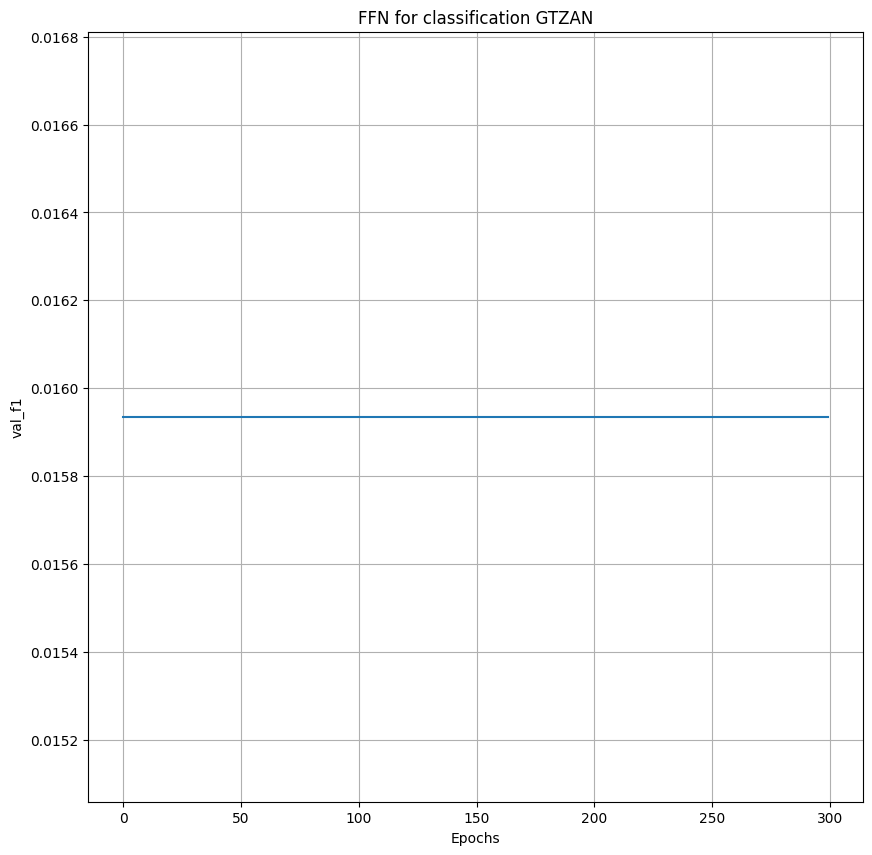

In [180]:
import matplotlib.pyplot as plt

plt.plot(val_f1_for_draw)
plt.title('FFN for classification GTZAN')
plt.xlabel('Epochs')
plt.ylabel('val_f1')
plt.grid()
plt.show()

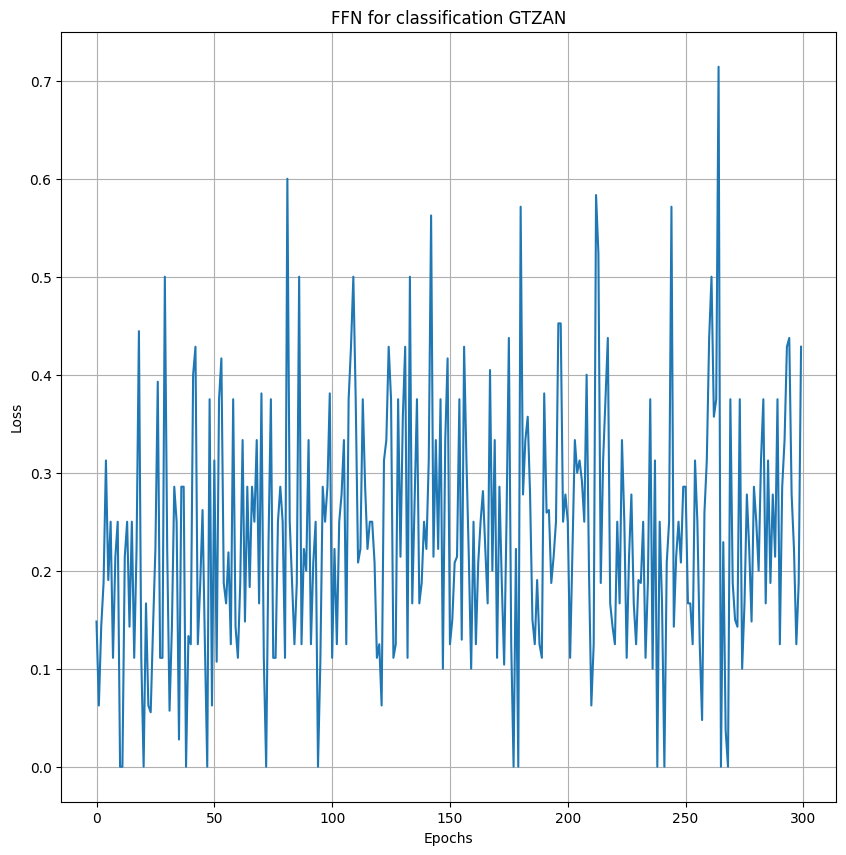

In [181]:
import matplotlib.pyplot as plt

plt.plot(train_accuracy_for_draw)
plt.title('FFN for classification GTZAN')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.grid()
plt.show()

In [183]:
acc, y_t, y_p = get_score(testloader, net)
acc

<ipython-input-162-95ec97eefdfc>:12: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  x = F.softmax(self.fc3(x))


0.28

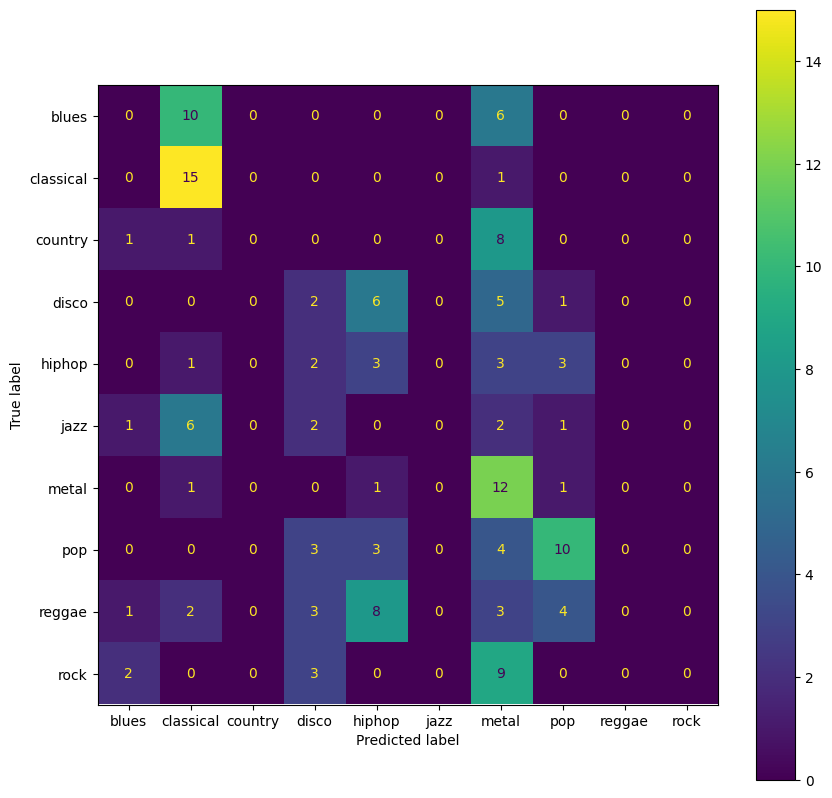

In [184]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_true_name = [num2class[i] for i in y_t]
y_pred_name = [num2class[i] for i in y_p]

experiment.log_confusion_matrix(y_true=y_t, y_predicted=y_p)

plt.rcParams['figure.figsize'] = [10, 10]
cm = confusion_matrix(y_true_name, y_pred_name, labels=list(num2class.values()))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=list(num2class.values()))
disp.plot()
plt.show()

# Сохраняем(лучшие варианты)

#### Базовая модель

In [ ]:
# Задание пути для сохранения чекпоинта
checkpoint_path = '/content/drive/MyDrive/ВычМуз/ЛР5/models/basic.pth'

# Создание словаря с параметрами для сохранения
checkpoint = {
    'model_state_dict': net.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    # Другие данные, если нужно
}

# Сохранение чекпоинта
torch.save(checkpoint, checkpoint_path)

####Батчсайз 8 модель

In [ ]:
# Задание пути для сохранения чекпоинта
checkpoint_path = '/content/drive/MyDrive/ВычМуз/ЛР5/models/batch_size8.pth'

# Создание словаря с параметрами для сохранения
checkpoint = {
    'model_state_dict': net.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    # Другие данные, если нужно
}

# Сохранение чекпоинта
torch.save(checkpoint, checkpoint_path)

In [ ]:
# Загрузка чекпоинта
checkpoint = torch.load(checkpoint_path)

# Восстановление модели и оптимизатора из чекпоинта
net.load_state_dict(checkpoint['model_state_dict'])
optimizer.load_state_dict(checkpoint['optimizer_state_dict'])